In [1]:
# Handling Missing Values
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
##Load the Dataset
df = pd.read_csv("DS.csv")

df.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,SNWD,TAVG,TMAX,TMIN
0,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/1/1993,0.0,10.0,-8.3,NaN,NaN
1,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/2/1993,NaN,10.0,-14.9,NaN,NaN
2,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/3/1993,0.0,10.0,-13.6,-9.7,NaN
3,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/4/1993,0.0,10.0,-10.5,-6.5,-13.3
4,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/5/1993,0.0,10.0,-12.0,-8.9,-14.1


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (10954, 11)


In [4]:
##understand the dataset before preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10954 entries, 0 to 10953
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    10954 non-null  object 
 1   NAME       10954 non-null  object 
 2   LATITUDE   10954 non-null  float64
 3   LONGITUDE  10954 non-null  float64
 4   ELEVATION  10954 non-null  float64
 5   DATE       10954 non-null  object 
 6   PRCP       9158 non-null   float64
 7   SNWD       1423 non-null   float64
 8   TAVG       10954 non-null  float64
 9   TMAX       7463 non-null   float64
 10  TMIN       5870 non-null   float64
dtypes: float64(8), object(3)
memory usage: 941.5+ KB


In [5]:
df.describe()

,LATITUDE,LONGITUDE,ELEVATION,PRCP,SNWD,TAVG,TMAX,TMIN
count,1.095400e+04,1.095400e+04,1.095400e+04,9158.000000,1423.000000,10954.000000,7463.000000,5870.000000
mean,5.216600e+01,2.096700e+01,1.103000e+02,1.790358,82.492621,9.114241,13.919188,4.685826
std,8.562431e-12,2.607811e-12,2.278104e-11,5.649012,85.352103,8.671128,9.699870,7.780249
min,5.216600e+01,2.096700e+01,1.103000e+02,0.000000,10.000000,-22.300000,-16.700000,-27.100000
25%,5.216600e+01,2.096700e+01,1.103000e+02,0.000000,20.000000,2.400000,6.200000,-0.500000
50%,5.216600e+01,2.096700e+01,1.103000e+02,0.000000,51.000000,9.300000,14.700000,4.900000
75%,5.216600e+01,2.096700e+01,1.103000e+02,1.500000,109.000000,16.200000,22.000000,10.800000
max,5.216600e+01,2.096700e+01,1.103000e+02,255.000000,531.000000,29.100000,37.000000,21.800000


In [6]:
## Identifying Missing Values
missing_values = df.isnull().sum()

print(missing_values)

STATION         0
NAME            0
LATITUDE        0
LONGITUDE       0
ELEVATION       0
DATE            0
PRCP         1796
SNWD         9531
TAVG            0
TMAX         3491
TMIN         5084
dtype: int64


In [7]:
##  Missing Value Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

STATION       0.000000
NAME          0.000000
LATITUDE      0.000000
LONGITUDE     0.000000
ELEVATION     0.000000
DATE          0.000000
PRCP         16.395837
SNWD         87.009312
TAVG          0.000000
TMAX         31.869637
TMIN         46.412269
dtype: float64


In [8]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Missing Percentage
PRCP,1796,16.395837
SNWD,9531,87.009312
TMAX,3491,31.869637
TMIN,5084,46.412269


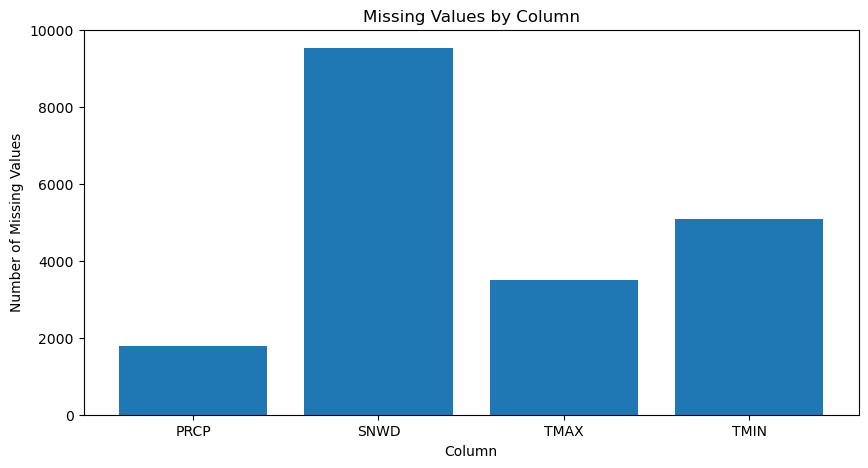

In [9]:
##  Visualization of Missing Values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 5))

plt.bar(missing_values.index, missing_values.values)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")

plt.show()

In [ ]:
### Interpretation
The visualization shows that missing values are present in four columns: PRCP, SNWD, TMAX, and TMIN.

SNWD has the highest number of missing values, with 9,531 missing entries, representing approximately 86.99% of the dataset. TMIN has the second-highest number of missing values, followed by TMAX and PRCP.

Therefore, the missing-value problem is particularly significant for the SNWD attribute.

In [10]:
# median values
print("PRCP median:", df["PRCP"].median())
print("TMAX median:", df["TMAX"].median())
print("TMIN median:", df["TMIN"].median())

PRCP median: 0.0
TMAX median: 14.7
TMIN median: 4.9


In [11]:
for column in ["PRCP", "TMAX", "TMIN"]:
    df[column] = df[column].fillna(df[column].median())

In [12]:
df["SNWD"] = df["SNWD"].fillna(df["SNWD"].median())
### SNWD Missing Values
SNWD has about 86.99% missing values. Since this is very high, median imputation may not be suitable. The treatment of SNWD should be discussed with the group before finalizing the preprocessing pipeline.

In [13]:
#. Verify the Preprocessing
print(df.isnull().sum())

STATION      0
NAME         0
LATITUDE     0
LONGITUDE    0
ELEVATION    0
DATE         0
PRCP         0
SNWD         0
TAVG         0
TMAX         0
TMIN         0
dtype: int64


In [15]:
#Compare Before and After
# Before preprocessing
before_missing = df.isnull().sum()

# Handle missing values
for column in ["PRCP", "TMAX", "TMIN"]:
    df[column] = df[column].fillna(df[column].median())

# After preprocessing
after_missing = df.isnull().sum()

comparison = pd.DataFrame({
    "Before": before_missing,
    "After": after_missing
})

comparison


,Before,After
STATION,0,0
NAME,0,0
LATITUDE,0,0
LONGITUDE,0,0
ELEVATION,0,0
DATE,0,0
PRCP,0,0
SNWD,0,0
TAVG,0,0
TMAX,0,0


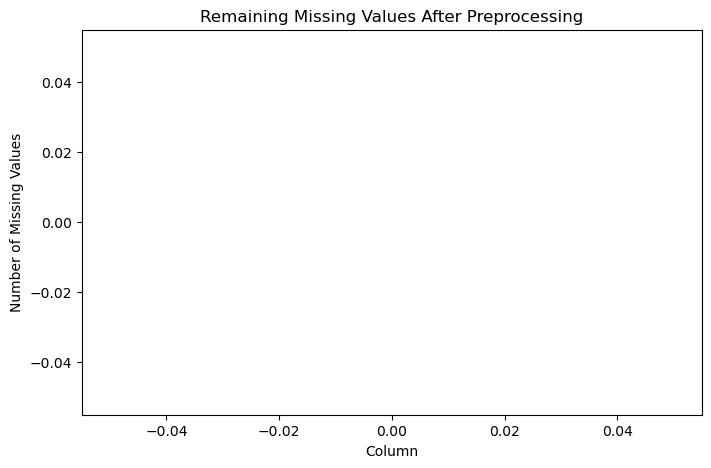

In [16]:
#Final Visualization
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

plt.figure(figsize=(8, 5))

plt.bar(remaining_missing.index, remaining_missing.values)

plt.title("Remaining Missing Values After Preprocessing")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")

plt.show()